In [33]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

In [34]:
# all data files paths
DATA_PATH =             Path("data/data.csv")
DATA_BY_ARTIST_PATH =   Path("data/data_by_artist.csv")
DATA_BY_GENRES_PATH =   Path("data/data_by_genres.csv")
DATA_BY_YEAR_PATH =     Path("data/data_by_year.csv")
DATA_W_GENRES_PATH =    Path("data/data_w_genres.csv")

In [35]:
# load file to dataframe
df = pd.read_csv(DATA_PATH)
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [36]:
# dropping rows with missing values and dropping identifier columns
df = df.dropna()
cols_to_drop = ["id", "artists", "name"]
df = df.drop(columns=cols_to_drop, errors="ignore")
df.head()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,4,1921,0.0366,80.954
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,5,1921,0.4150,60.936
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,5,1921,0.0339,110.339
3,0.1650,1921,0.967,0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,3,1921,0.0354,100.109
4,0.2530,1921,0.957,0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,2,1921,0.0380,101.665


In [37]:
popularity_threshold = 60
hit_song_count = (df["popularity"] > popularity_threshold).sum()
print(f"total number of songs: ", len(df))
print(f"number of songs with pop over {popularity_threshold}: ", hit_song_count)
print(f"percentage of songs with pop over {popularity_threshold}: ", hit_song_count / len(df) * 100)

total number of songs:  170653
number of songs with pop over 60:  15900
percentage of songs with pop over 60:  9.317152350090534


In [38]:
# creating binary target column 'hit'
df["hit"] = (df["popularity"] >= popularity_threshold).astype(int)
# getting hit value_counts
df["hit"].value_counts(normalize=True)

hit
0    0.897148
1    0.102852
Name: proportion, dtype: float64

In [39]:
df.head()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,release_date,speechiness,tempo,hit
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,4,1921,0.0366,80.954,0
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,5,1921,0.4150,60.936,0
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,5,1921,0.0339,110.339,0
3,0.1650,1921,0.967,0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,3,1921,0.0354,100.109,0
4,0.2530,1921,0.957,0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,2,1921,0.0380,101.665,0


In [40]:
# dropping popularity and release_date
cols_to_drop = ["popularity", "release_date"]
df = df.drop(columns=cols_to_drop, errors="ignore")
df.head()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,hit
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,0.0366,80.954,0
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,0.4150,60.936,0
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,0.0339,110.339,0
3,0.1650,1921,0.967,0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,0.0354,100.109,0
4,0.2530,1921,0.957,0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,0.0380,101.665,0


In [41]:
# making different datasets for testing 

# temporal split pre-2000 and post-2000
df_pre_2000 = df[df["year"] < 2000].copy()
df_post_2000 = df[df["year"] >= 2000].copy()

# with and without year
df_with_year = df.copy()
df_without_year = df.drop(columns=["year"], errors="ignore")



In [42]:
df_without_year.head()

,valence,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,hit
0,0.0594,0.982,0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,0.0366,80.954,0
1,0.9630,0.732,0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,0.4150,60.936,0
2,0.0394,0.961,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,0.0339,110.339,0
3,0.1650,0.967,0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,0.0354,100.109,0
4,0.2530,0.957,0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,0.0380,101.665,0


In [43]:
# training and testing split 
# base
RANDOM_STATE = 42
X = df.drop(columns=["hit"], errors="ignore")
y = df["hit"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# without year
X_no_year = df_without_year.drop(columns=["hit"], errors="ignore")
y_no_year = df_without_year["hit"]
X_train_no_year, X_test_no_year, y_train_no_year, y_test_no_year = train_test_split(
    X_no_year, y_no_year, test_size=0.2, random_state=RANDOM_STATE
)



In [44]:
# metric function
def evaluate_model(y_true, y_pred, print_report=True):
    if print_report:
        print("Classification Report:")
        print(classification_report(y_true, y_pred))
        
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    avg_precision = average_precision_score(y_true, y_pred)

    return precision, recall, f1, accuracy, roc_auc, avg_precision

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier

# model training function

def training_pipeline(X_train, y_train, X_test, y_test):
    results = []
    
    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "SGD Classifier": SGDClassifier(loss="log_loss", random_state=RANDOM_STATE)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        precision, recall, f1, accuracy, roc_auc, avg_precision = evaluate_model(y_test, y_pred, print_report=False)

        results.append({
            "Model": name,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Accuracy": accuracy,
            "ROC AUC": roc_auc,
            "Average Precision": avg_precision, 

            "y_test": y_test, # for later analysis like confusion matrix or ROC curve
            "y_pred": y_pred
        })

    return pd.DataFrame(results)

In [46]:
# getting data shapes
print("Base data shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)



Base data shapes:
X_train: (136522, 14)
y_train: (136522,)
X_test: (34131, 14)
y_test: (34131,)


In [57]:
# number of hit songs
hit_song_count = (df["hit"] == 1).sum()
print(f"Number of hit songs: {hit_song_count}")

Number of hit songs: 17552


In [58]:
# hit soung count in train and test sets
print(f"Number of hit songs in training set: {(y_train == 1).sum()}")
print(f"Number of hit songs in test set: {(y_test == 1).sum()}")


Number of hit songs in training set: 14009
Number of hit songs in test set: 3543


In [47]:
# pipe training

# no edit data
base_data_results = training_pipeline(X_train, y_train, X_test, y_test)

# without year
no_year_results = training_pipeline(X_train_no_year, y_train_no_year, X_test_no_year, y_test_no_year)



c:\Users\longt\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
base_data_results

,Model,Precision,Recall,F1 Score,Accuracy,ROC AUC,Average Precision,y_test,y_pred
0,Logistic Regression,0.246609,0.774767,0.374131,0.730919,0.750304,0.214445,116368 0 161935 0 135703 0 112288 ...,"[0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, ..."
1,Random Forest,0.755092,0.449901,0.563849,0.927749,0.716500,0.396820,116368 0 161935 0 135703 0 112288 ...,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Decision Tree,0.443639,0.466554,0.454808,0.883889,0.699391,0.262356,116368 0 161935 0 135703 0 112288 ...,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,SGD Classifier,0.000000,0.000000,0.000000,0.895344,0.499526,0.103806,116368 0 161935 0 135703 0 112288 ...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Confusion Matrix for Logistic Regression:


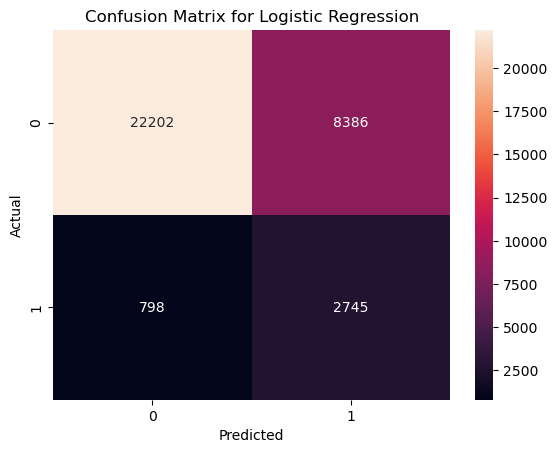

Confusion Matrix for Random Forest:


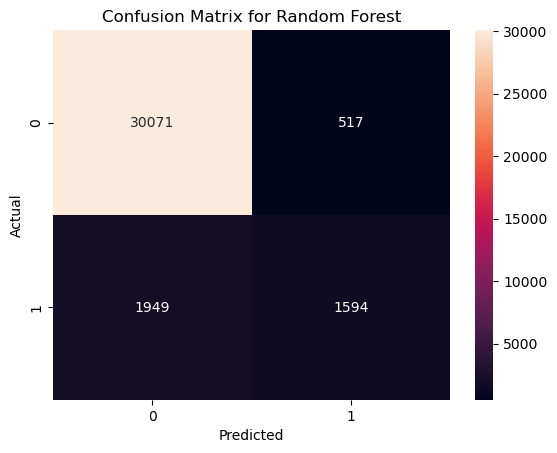

Confusion Matrix for Decision Tree:


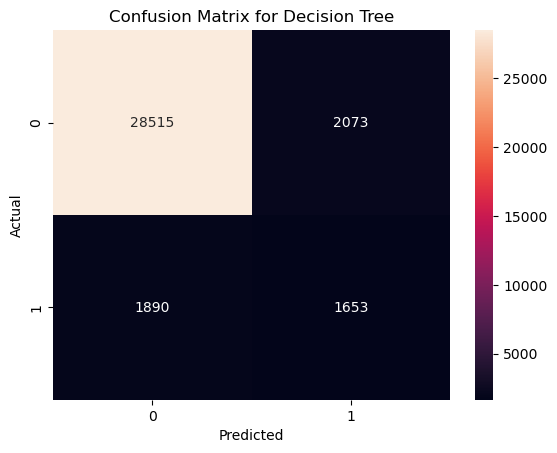

Confusion Matrix for SGD Classifier:


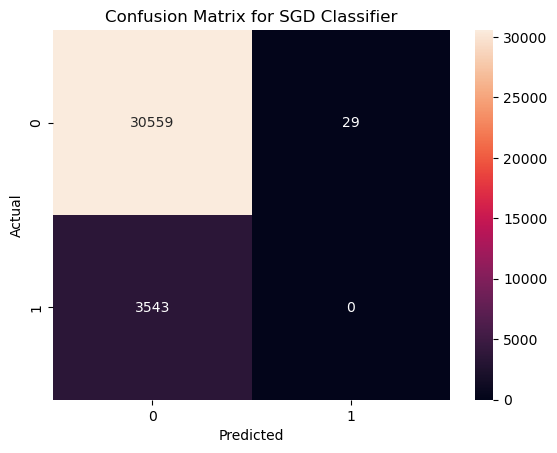

In [49]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# going through each models results and printing confusion matrix
for index, row in base_data_results.iterrows():
    print(f"Confusion Matrix for {row['Model']}:")
    cm = confusion_matrix(row["y_test"], row["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {row['Model']}")
    plt.show()

In [50]:
no_year_results

,Model,Precision,Recall,F1 Score,Accuracy,ROC AUC,Average Precision,y_test,y_pred
0,Logistic Regression,0.246438,0.771380,0.373539,0.731417,0.749084,0.213830,116368 0 161935 0 135703 0 112288 ...,"[0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, ..."
1,Random Forest,0.626906,0.197290,0.300129,0.904486,0.591845,0.207009,116368 0 161935 0 135703 0 112288 ...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Decision Tree,0.300906,0.318657,0.309527,0.852422,0.616452,0.166613,116368 0 161935 0 135703 0 112288 ...,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,SGD Classifier,0.000000,0.000000,0.000000,0.896135,0.499967,0.103806,116368 0 161935 0 135703 0 112288 ...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Confusion Matrix for Logistic Regression:


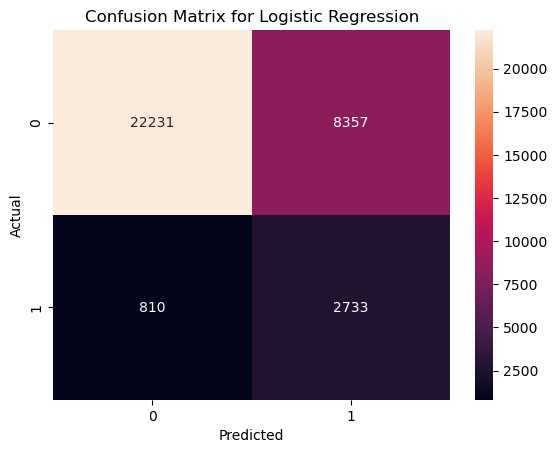

Confusion Matrix for Random Forest:


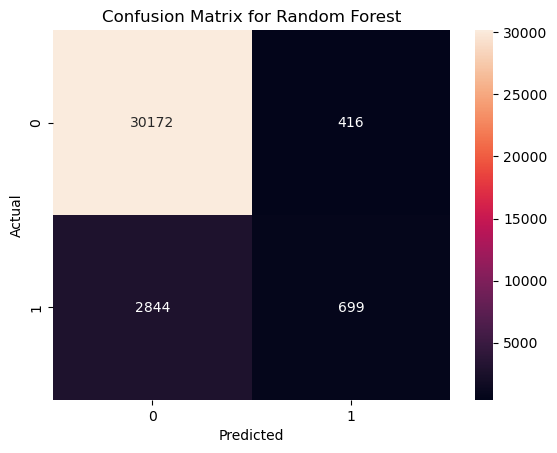

Confusion Matrix for Decision Tree:


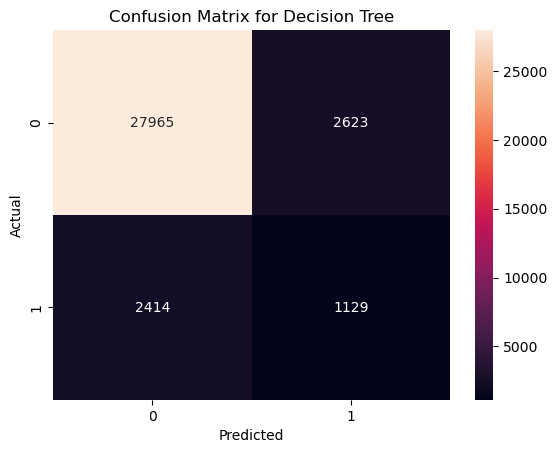

Confusion Matrix for SGD Classifier:


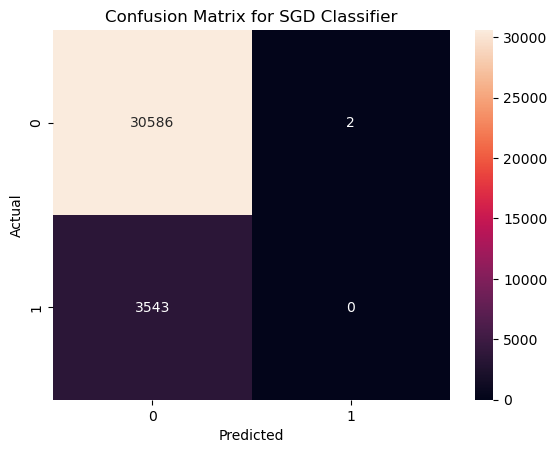

In [51]:
# going through each models results and printing confusion matrix
for index, row in no_year_results.iterrows():
    print(f"Confusion Matrix for {row['Model']}:")
    cm = confusion_matrix(row["y_test"], row["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {row['Model']}")
    plt.show()

In [56]:
# temporal split, train on pre 2000 and test on post 2000m without use the df_pre_2000 and df_post_2000, just use the original df but filter by year in the training and testing split
X_train_pre_2000 = df[df["year"] < 2000].drop(columns=["hit"], errors="ignore")
y_train_pre_2000 = df[df["year"] < 2000]["hit"]
X_test_post_2000 = df[df["year"] >= 2000].drop(columns=["hit"], errors="ignore")
y_test_post_2000 = df[df["year"] >= 2000]["hit"]

# and drop year column for this split as well because it would be a data leak to use year as a feature when we are splitting by year

temporal_split_results = training_pipeline(X_train_pre_2000, y_train_pre_2000, X_test_post_2000, y_test_post_2000)

c:\Users\longt\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\longt\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
temporal_split_results


,Model,Precision,Recall,F1 Score,Accuracy,ROC AUC,Average Precision,y_test,y_pred
0,Logistic Regression,0.350409,0.854687,0.497039,0.422195,0.529974,0.348030,15606 1 15607 1 15608 1 15609 ...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Random Forest,0.296296,0.000578,0.001153,0.665694,0.499945,0.334019,15606 1 15607 1 15608 1 15609 ...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Decision Tree,0.345532,0.134335,0.193458,0.625838,0.503354,0.335585,15606 1 15607 1 15608 1 15609 ...,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
3,SGD Classifier,0.000000,0.000000,0.000000,0.665959,0.500000,0.334041,15606 1 15607 1 15608 1 15609 ...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Confusion Matrix for Logistic Regression:


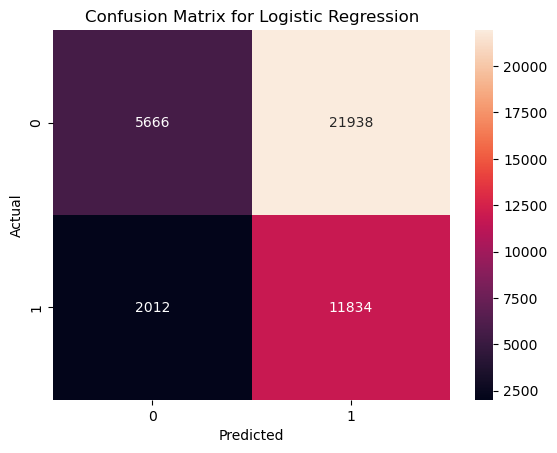

Confusion Matrix for Random Forest:


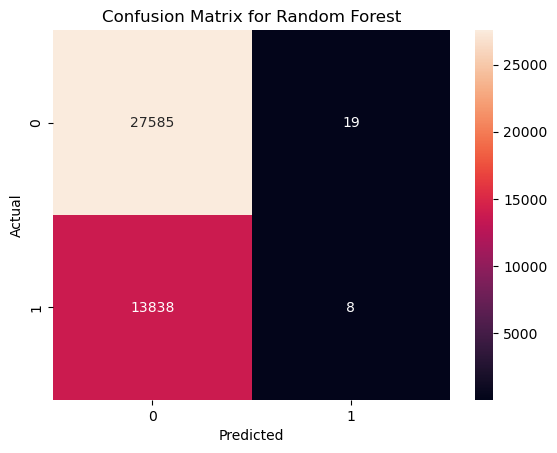

Confusion Matrix for Decision Tree:


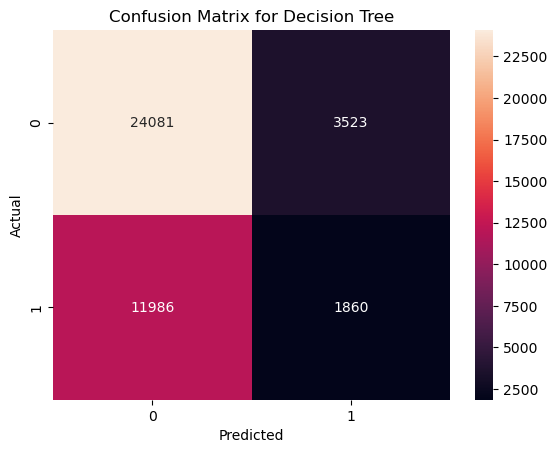

Confusion Matrix for SGD Classifier:


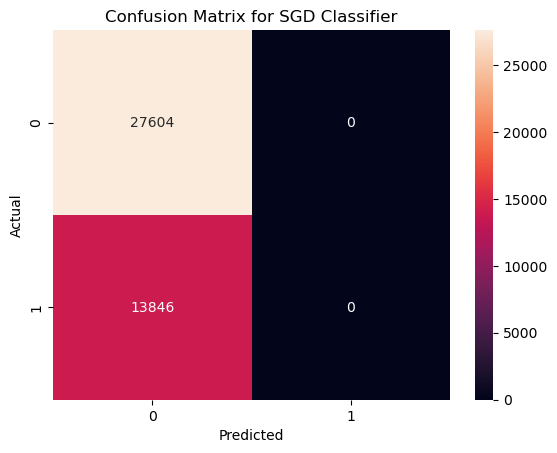

In [55]:
# going through each models results and printing confusion matrix
for index, row in temporal_split_results.iterrows():
    print(f"Confusion Matrix for {row['Model']}:")
    cm = confusion_matrix(row["y_test"], row["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {row['Model']}")
    plt.show()

In [18]:
# indiviual model training 

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression(max_iter=2000, random_state=42)
lr_clf.fit(X_train, y_train)
y_pred_lr = lr_clf.predict(X_test)

lr_clf_no_year = LogisticRegression(max_iter=2000, random_state=42)
lr_clf_no_year.fit(X_train_no_year, y_train_no_year)
y_pred_lr_no_year = lr_clf_no_year.predict(X_test_no_year)

evaluate_model(y_test, y_pred_lr)
evaluate_model(y_test_no_year, y_pred_lr_no_year)



Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     33177
           1       0.44      0.00      0.01       954

    accuracy                           0.97     34131
   macro avg       0.71      0.50      0.50     34131
weighted avg       0.96      0.97      0.96     34131

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     33177
           1       0.50      0.00      0.00       954

    accuracy                           0.97     34131
   macro avg       0.74      0.50      0.50     34131
weighted avg       0.96      0.97      0.96     34131



(0.5,
 0.0020964360587002098,
 0.0041753653444676405,
 0.9720488705282587,
 0.5010180766663577,
 0.02894074974538538)

In [19]:
# SGD Classifier
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(loss="log_loss", random_state=42)
sgd_clf.fit(X_train, y_train)
y_pred_sgd = sgd_clf.predict(X_test)

sgd_clf_no_year = SGDClassifier(loss="log_loss", random_state=42)
sgd_clf_no_year.fit(X_train_no_year, y_train_no_year)
y_pred_sgd_no_year = sgd_clf_no_year.predict(X_test_no_year)

evaluate_model(y_test, y_pred_sgd)
evaluate_model(y_test_no_year, y_pred_sgd_no_year)


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     33177
           1       0.00      0.00      0.00       954

    accuracy                           0.97     34131
   macro avg       0.49      0.50      0.49     34131
weighted avg       0.94      0.97      0.96     34131

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     33177
           1       0.00      0.00      0.00       954

    accuracy                           0.97     34131
   macro avg       0.49      0.50      0.49     34131
weighted avg       0.94      0.97      0.96     34131



(0.0, 0.0, 0.0, 0.9719609738946998, 0.49995478795551135, 0.02795112947174123)

In [20]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

dt_clf_no_year = DecisionTreeClassifier(random_state=42)
dt_clf_no_year.fit(X_train_no_year, y_train_no_year)
y_pred_dt_no_year = dt_clf_no_year.predict(X_test_no_year)

evaluate_model(y_test, y_pred_dt)
evaluate_model(y_test_no_year, y_pred_dt_no_year)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     33177
           1       0.25      0.31      0.28       954

    accuracy                           0.95     34131
   macro avg       0.62      0.64      0.63     34131
weighted avg       0.96      0.95      0.96     34131

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     33177
           1       0.14      0.17      0.15       954

    accuracy                           0.95     34131
   macro avg       0.56      0.57      0.56     34131
weighted avg       0.95      0.95      0.95     34131



(0.13737201365187712,
 0.16876310272536688,
 0.15145813734713076,
 0.9471448243532272,
 0.5691450923700078,
 0.04641733738893398)

In [21]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

rf_clf_no_year = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_no_year.fit(X_train_no_year, y_train_no_year)
y_pred_rf_no_year = rf_clf_no_year.predict(X_test_no_year)

evaluate_model(y_test, y_pred_rf)
evaluate_model(y_test_no_year, y_pred_rf_no_year)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     33177
           1       0.54      0.19      0.28       954

    accuracy                           0.97     34131
   macro avg       0.76      0.59      0.63     34131
weighted avg       0.96      0.97      0.97     34131

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     33177
           1       0.38      0.04      0.07       954

    accuracy                           0.97     34131
   macro avg       0.68      0.52      0.53     34131
weighted avg       0.96      0.97      0.96     34131



(0.38144329896907214,
 0.03878406708595388,
 0.07040913415794481,
 0.9713749963376402,
 0.5184877926532039,
 0.041660993487885094)

In [22]:
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors=2)
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)

knn_clf_no_year = KNeighborsClassifier(n_neighbors=2)
knn_clf_no_year.fit(X_train_no_year, y_train_no_year)
y_pred_knn_no_year = knn_clf_no_year.predict(X_test_no_year)

evaluate_model(y_test, y_pred_knn)
evaluate_model(y_test_no_year, y_pred_knn_no_year)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     33177
           1       0.25      0.03      0.05       954

    accuracy                           0.97     34131
   macro avg       0.61      0.51      0.52     34131
weighted avg       0.95      0.97      0.96     34131

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     33177
           1       0.08      0.01      0.01       954

    accuracy                           0.97     34131
   macro avg       0.53      0.50      0.50     34131
weighted avg       0.95      0.97      0.96     34131



(0.08064516129032258,
 0.005241090146750524,
 0.00984251968503937,
 0.970525328879904,
 0.501761516228091,
 0.028227303642698157)